In [1]:
#library(locfit) #5164076665 6318283110

In [2]:
Output = ('/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1016. THC Adducts/P1016.3. Analyses/P1016.3.1. Data Normalization/Output')
cur_date = "091726"

library(readxl)
library(openxlsx)
library(tidyverse)
library(reshape2)
library(data.table)
library(factoextra)
library(ggrepel)
library(pheatmap)
library(DESeq2)

# reading in files
count_df = data.frame(read_excel("Input/THC_Adducts_091426.xlsx", sheet = 3)) 
#subject_info_df = data.frame(read_excel("Input/SubjectInfo_120223.xlsx", sheet = 2))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘data.table’


The following objects are masked from ‘package:reshape2’:

    dcast, melt


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from

In [3]:
head(count_df)

,ENSEMBL_ID,P1_Control,P2_Control,P3_Control,P1_D8THC,P2_D8THC,P3_D8THC,P1_D8THCq,P2_D8THCq,P3_D8THCq
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000223972,0,0,0,0,0,1,0,0,0
2,ENSG00000227232,137,107,140,119,153,112,47,137,10
3,ENSG00000278267,3,1,11,14,2,7,0,6,1
4,ENSG00000243485,3,0,0,2,0,1,0,0,0
5,ENSG00000237613,0,0,0,0,0,0,0,0,0
6,ENSG00000268020,0,0,0,0,0,0,0,0,0


In [4]:
# reformatting for the deseq2 function
countdata = count_df %>%
    column_to_rownames(var = "ENSEMBL_ID")
head(countdata)

,P1_Control,P2_Control,P3_Control,P1_D8THC,P2_D8THC,P3_D8THC,P1_D8THCq,P2_D8THCq,P3_D8THCq
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000223972,0,0,0,0,0,1,0,0,0
ENSG00000227232,137,107,140,119,153,112,47,137,10
ENSG00000278267,3,1,11,14,2,7,0,6,1
ENSG00000243485,3,0,0,2,0,1,0,0,0
ENSG00000237613,0,0,0,0,0,0,0,0,0
ENSG00000268020,0,0,0,0,0,0,0,0,0


In [5]:
nrow(countdata)

[1] 57500

# Transcriptomics QA/QC

Performed on raw count data to identify potential outlier samples. Starting by filtering lowly expressed genes.

In [6]:
# First count the total number of samples and save it as a value in the global environment
nsamp <- ncol(countdata)

# Then, calculate the median expression level across all genes and all samples and save it as a value
total_median <- median(as.matrix(countdata), na.rm = TRUE)

# We need to temporarily add back in the gene column to the countdata 
# so we can filter for genes that pass the background filter
countdata <- countdata %>% 
    rownames_to_column("Gene")

head(countdata)

,Gene,P1_Control,P2_Control,P3_Control,P1_D8THC,P2_D8THC,P3_D8THC,P1_D8THCq,P2_D8THCq,P3_D8THCq
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000223972,0,0,0,0,0,1,0,0,0
2,ENSG00000227232,137,107,140,119,153,112,47,137,10
3,ENSG00000278267,3,1,11,14,2,7,0,6,1
4,ENSG00000243485,3,0,0,2,0,1,0,0,0
5,ENSG00000237613,0,0,0,0,0,0,0,0,0
6,ENSG00000268020,0,0,0,0,0,0,0,0,0


In [7]:
# filtering for genes that have an expression greater than the total median in at least 20% of the samples
genes_above_background <- countdata %>% 
    pivot_longer(cols =! Gene, names_to = "SampleID", values_to = "expression") %>% 
    # indicates whether the expression of a gene for the corresponding exposure condition is above (1) or not 
    # above (0) the median of all count data
    mutate(above_median = ifelse(expression > total_median, 1, 0)) %>% 
    group_by(Gene) %>% 
    # For each gene, count the number of exposure conditions where the expression was greater than the median 
    # of all count data
    summarize(total_above_median = sum(above_median)) %>% 
    # Filter for genes that have expression above the median in at least 20% of the samples
    filter(total_above_median >= 0.2 * nsamp) %>% 
    select(Gene) 

# Then filter the original 'countdata' dataframe for only the genes above background. 
countdata <- left_join(genes_above_background, countdata, by = "Gene")

dim(countdata)

[1] 28893    10

This dataframe went from having 57,500 genes to 28,893 genes. Now filtering samples with no expression.

In [8]:
countdata_T <- countdata %>% 
  pivot_longer(cols =! Gene, names_to = "Sample_ID",values_to = "expression") %>% 
  pivot_wider(names_from = Gene, values_from = expression)

# Then add in a column to the transposed countdata dataframe that sums expression across all genes for each 
# exposure condition
countdata_T$rowsum <- rowSums(countdata_T[2:ncol(countdata_T)])

# Remove samples that have no expression
countdata_T <- countdata_T %>% 
    filter(rowsum != 0)

# Take the count data filtered for correct samples, remove the 'rowsums' column
countdata_T <- countdata_T %>% 
    select(!rowsum) 

# Then, transpose it back to the correct format for analysis
countdata <- countdata_T %>%
  pivot_longer(cols =! Sample_ID, names_to = "Gene", values_to = "expression") %>% 
  pivot_wider(names_from = Sample_ID, values_from = "expression") %>%
    column_to_rownames(var = "Gene")

dim(countdata)

[1] 28893     9

No samples were removed. Now finding and removing sample outliers using PCA and hierarchical clustering.

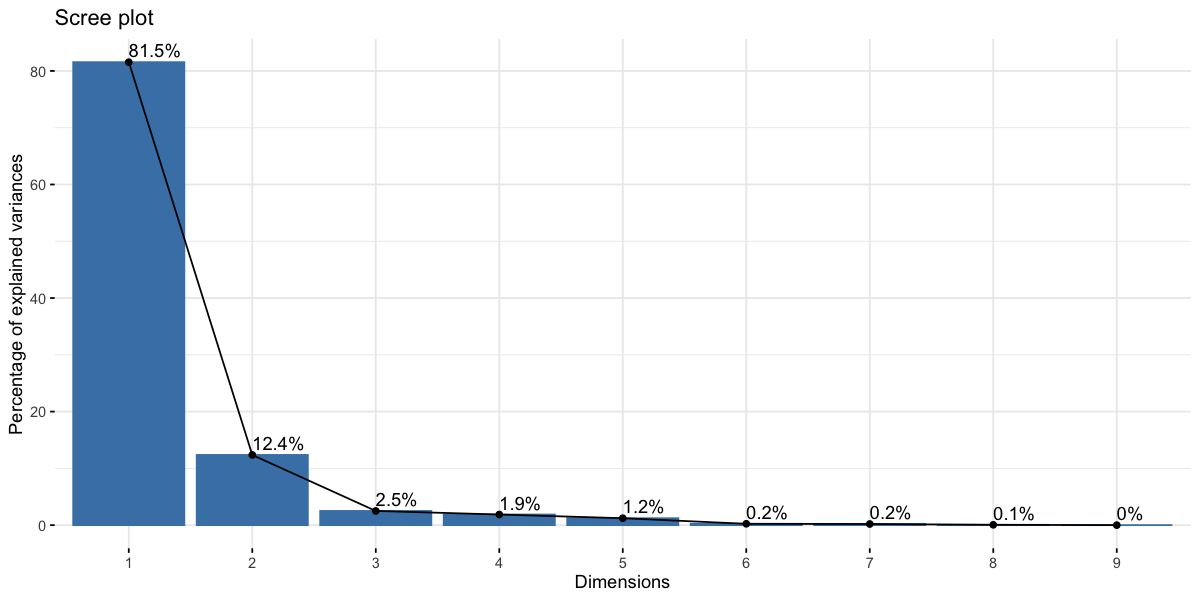

In [9]:
# PCA helps in identifying outlying samples for quality control and gives a feeling for the principal causes of 
# variation in a dataset

# Calculate principal components using transposed count data
pca <- prcomp(t(countdata))

options(repr.plot.width = 10, repr.plot.height = 5) #changing size
fviz_eig(pca, addlabels = TRUE)

In [11]:
# Make dataframe for PCA plot generation using first two components and the sample name
pca_df <- data.frame(PC1 = pca$x[,1], PC2 = pca$x[,2], Sample_ID = colnames(countdata))

# Calculating percent of the variation that is captured by each principal component
pca_percent <- round(100 * pca$sdev^2/sum(pca$sdev^2), 1)

# Organize dataframe so we can color our points by burn condition
# pca_df <- pca_df %>% 
#     inner_join(coldata)

head(pca_df)

,PC1,PC2,Sample_ID
,<dbl>,<dbl>,<chr>
P1_Control,-87723.55,33208.724,P1_Control
P2_Control,-87645.07,-67535.067,P2_Control
P3_Control,-70505.69,2478.568,P3_Control
P1_D8THC,-80636.85,39992.418,P1_D8THC
P2_D8THC,-91683.72,7789.444,P2_D8THC
P3_D8THC,-70958.14,50036.803,P3_D8THC


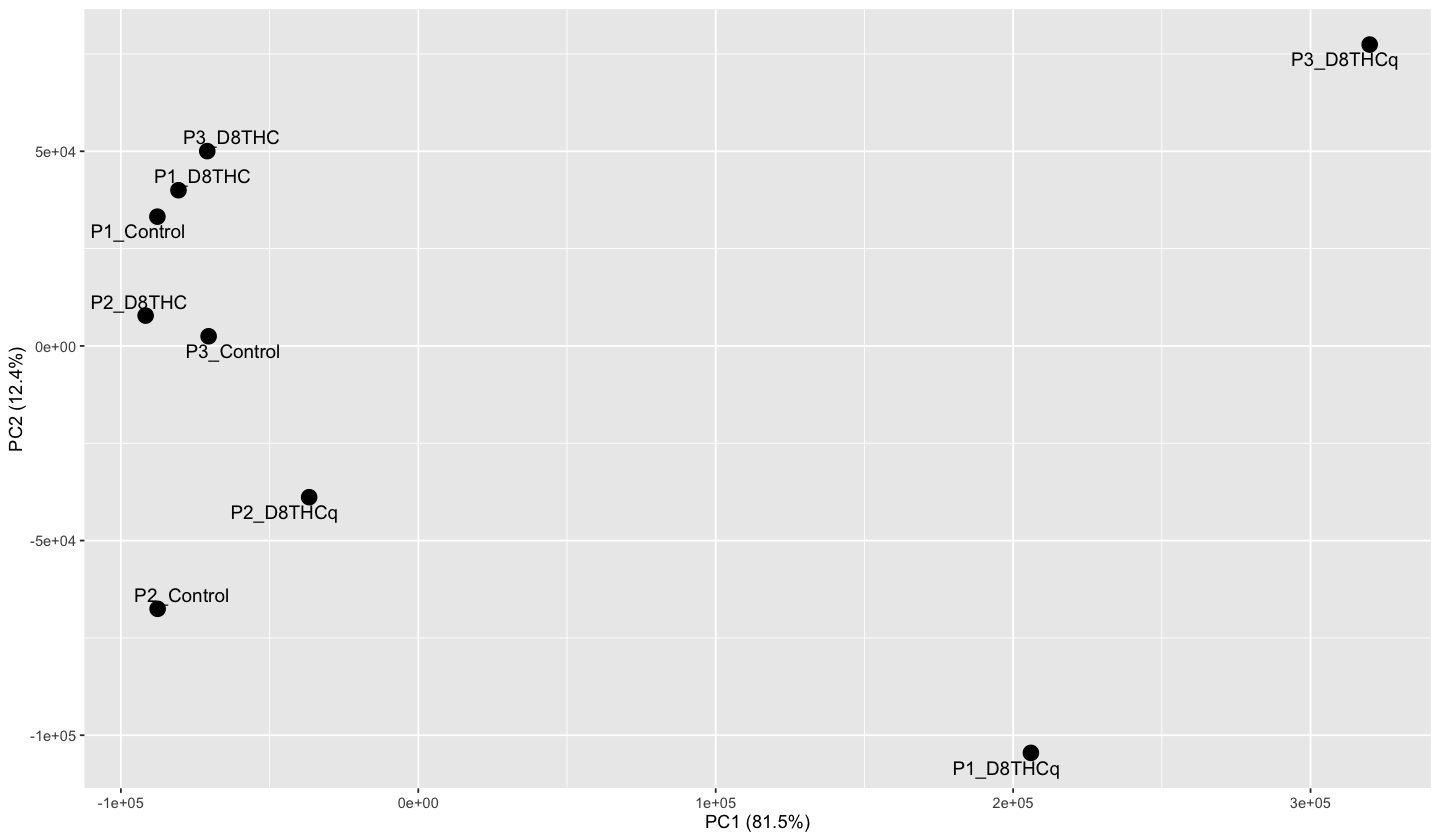

In [12]:
options(repr.plot.width=12, repr.plot.height=7) #changing size

# color by sex since that's a covariate we're interested in
ggplot(pca_df, aes(PC1, PC2)) +
  geom_point(size = 4) +
  geom_text_repel(aes(label = Sample_ID), size = 4) +
  labs(x = paste0("PC1 (",pca_percent[1],"%)"), y = paste0("PC2 (",pca_percent[2],"%)"))

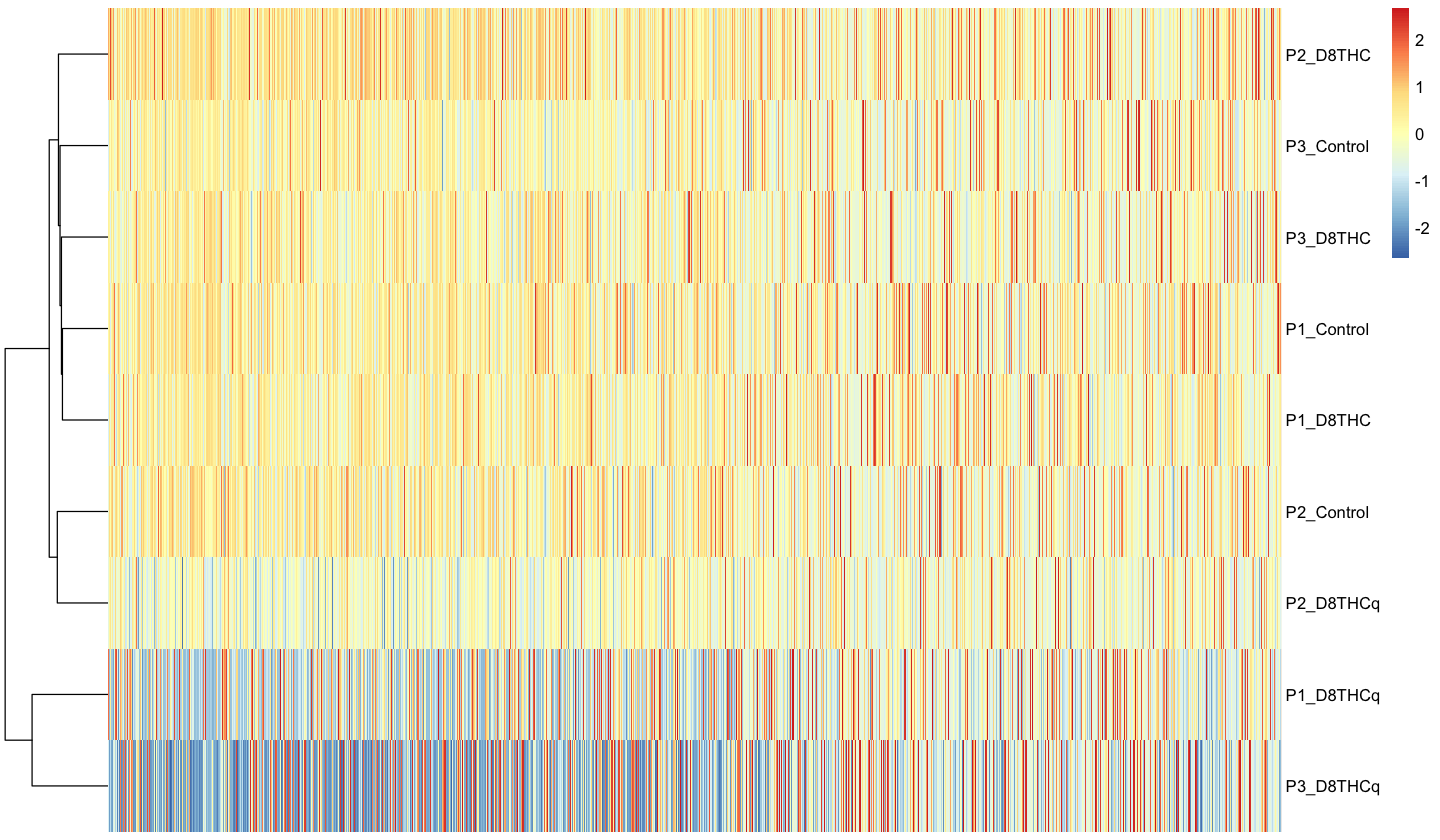

In [13]:
countdata_for_clustering <- t(countdata)

pheatmap(scale(countdata_for_clustering), 
         cluster_rows = TRUE, cluster_cols = FALSE, fontsize_col = 7, treeheight_row = 60, show_colnames = FALSE)

There might be two outliers from PCA or hierarchical clustering, so now we'll use a quantitative approach. The standard way to detect outliers in genetics is the criterion of being “more than 6 standard deviations away from the mean”. [source](https://privefl.github.io/blog/detecting-outlier-samples-in-pca/)

In [14]:
outlier_detection = function(pca_df){
    # """
    # Creating a scoring function for to detect PCA sample outliers. 
    # :param (input): PCA df (df)
    # :output: outlier names
    # """
    
    # getting scores
    scores = pca_df$x
    # identifying samples that are > 6 standard deviations away from the mean
    outlier_indices = apply(scores, 2, function(x) which( abs(x - mean(x)) > (6 * sd(x)) )) %>%
        Reduce(union, .)
    # getting sample names
    outliers = rownames(scores)[outlier_indices]
    
    return(outliers)
}

# calling fn
gene_outliers = outlier_detection(pca)  

In [15]:
# getting length
length(gene_outliers)

[1] 0

There were no sample or gene outliers.